In [1]:
import pandas as pd
df = pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
df.shape

(1460, 81)

Data cleaning

In [3]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [4]:
df = df.drop(columns=['PoolQC','MiscFeature','Alley','Fence'])

In [5]:
df.shape

(1460, 77)

In [6]:
cols = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']
for col in cols:
  df[col] = df[col].fillna(df[col].median())

In [7]:
cols = ['FireplaceQu',
'GarageType',
'GarageFinish',
'GarageQual',
'GarageCond',
'BsmtFinType2',
'BsmtExposure',
'BsmtCond',
'BsmtQual',
'BsmtFinType1',
'MasVnrType',
'Electrical']
for col in cols:
  df[col] = df[col].fillna('None')

In [8]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
LotShape,0
LandContour,0
Utilities,0
LotConfig,0


Visualization

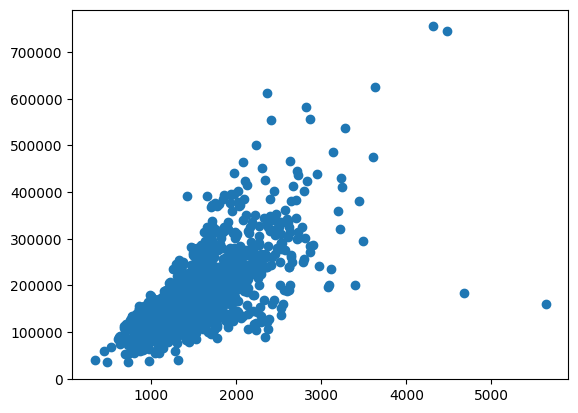

In [9]:
import matplotlib.pyplot as plt
plt.scatter(df['GrLivArea'],df['SalePrice'])
plt.show()

In [10]:
df = df[df['GrLivArea'] < 4000]

In [11]:
X = df[['GrLivArea']]
Y = df['SalePrice']

Train the Model

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [14]:
predictions = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(predictions, Y_test)

40085.9819474108

Model improvement

In [16]:
X = df[['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'GarageCars']]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
model.fit(X_train, Y_train)
predictions = model.predict(X_test)
mean_absolute_error(predictions, Y_test)

24530.562046474228

Model improvement 2

In [18]:
df_encoded = pd.get_dummies(df, columns=['Neighborhood'])
df_encoded.shape

(1456, 101)

In [19]:
neighborhood_cols = [col for col in df_encoded.columns if 'Neighborhood_' in col]
print(neighborhood_cols)

['Neighborhood_Blmngtn', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Neighborhood_Timber', 'Neighborhood_Veenker']


In [22]:
features = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'GarageCars']+ neighborhood_cols
X = df_encoded[features]

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
model.fit(X_train, Y_train)
predictions = model.predict(X_test)
mean_absolute_error(predictions, Y_test)

21685.796199937573

Model improvement 3

In [24]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, Y_train)
predictions = model.predict(X_test)
mean_absolute_error(predictions, Y_test)

19149.26992506523